# 2. Label Smoothing进阶（1）

## 2.0 上节内容回顾与本节主要内容介绍

在上一节中，我们学习了Label Smoothing分类损失，并用一个类实现了Label Smoothing分类损失。

在本节中，我们将继续关于Label Smoothing的实验与研究。本实验的主要内容为采用PyTorch等技术，使用Label Smoothing分类损失训练LeNet-5模型，最后对比该模型与不使用Label Smoothing的标准LeNet-5模型在对抗性攻击算法下的表现。

## 2.1 导入相关模块

In [1]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import importlib.util
import logging
import os
import test; test_fn = test.test

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

from loss import CWLoss, LabelSmoothingCrossEntropyLoss
from models import LeNet5
from pgd import LinfPGD
from utils import load_mnist_test

logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

In [2]:
# 上一节中实现的Label Smoothing分类损失
class LabelSmoothingCrossEntropyLoss(nn.Module):
    def __init__(self, label_smoothing=0.0, reduction='mean'):
        super(LabelSmoothingCrossEntropyLoss, self).__init__()
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, y, target):
        # 获取总类别数
        c = y.shape[1]
        
        # 将target转化为label smoothing的soft label
        # 1) 将target转化为one-hot形式的概率向量，此处torch.scatter函数在全0向量的指定位置写入1.，
        # 参考https://pytorch.org/docs/1.7.1/tensors.html?highlight=torch%20scatter#torch.Tensor.scatter
        soft_one_hot = torch.scatter(torch.zeros_like(y), dim=1, index=target.unsqueeze(1), value=1.)
        # 2) 定义均匀分布概率向量
        soft_uniform = 1/c * torch.ones_like(y)
        # 3) 计算label smoothing soft label
        soft_label = self.label_smoothing * soft_uniform + (1 - self.label_smoothing) * soft_one_hot

        # 计算交叉熵损失
        loss = (-F.log_softmax(y, dim=1) * soft_label).sum(dim=1)
        if self.reduction == 'sum':
            return loss.sum()
        elif self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'none':
            return loss
        else:
            raise NotImplementedError

## 2.2 使用Label Smoothing分类损失训练LeNet-5

### 2.2.1 模型训练

In [3]:
# 超参数
EPOCH = 50              # 训练总epoch数
BATCH_SIZE = 256        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）
LS_LAMBDA = 0.9         # Label Smoothing参数

# 检查数据集路径是否存在以及数据集是否存在
if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [5]:
# 定义网络结构并统计模型参数
from models import LeNet5

cnn = LeNet5().to(device)
print(cnn)  # 网络结构（这也是PyTorch的一大优点，即可用print很方便的得到网络的直观形式）

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 设置Label Smoothing超参数
loss_function = LabelSmoothingCrossEntropyLoss(label_smoothing=LS_LAMBDA)

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [6]:
train_accs = []
train_losses = []
test_accs = []
test_losses = []

for epoch in range(EPOCH):
    # 训练
    cnn.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn(inputs)

        loss = loss_function(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.max(dim=1).indices        
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.data.item() * n
        
    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    logger.info(f'training epoch: {epoch}, loss: {train_loss / train_total:.7f}, acc: {100 * train_correct / train_total:.2f}%')

    # 测试
    cnn.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn(inputs)
            loss = loss_function(outputs, labels)
            

            pred = outputs.max(dim=1).indices  
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.data.item() * n

    test_accs.append(test_correct / test_total)
    test_losses.append(test_loss / test_total)

    logger.info(f'    test epoch: {epoch}, loss: {test_loss / test_total:.7f}, acc: {100 * test_correct / test_total:.2f}%')

 31768 20260201 17:27:28 training epoch: 0, loss: 2.2741218, acc: 90.85%
 31768 20260201 17:27:30     test epoch: 0, loss: 2.2689063, acc: 97.71%
 31768 20260201 17:27:42 training epoch: 1, loss: 2.2683575, acc: 98.00%
 31768 20260201 17:27:44     test epoch: 1, loss: 2.2678279, acc: 98.34%
 31768 20260201 17:27:56 training epoch: 2, loss: 2.2676092, acc: 98.51%
 31768 20260201 17:27:58     test epoch: 2, loss: 2.2674121, acc: 98.59%
 31768 20260201 17:28:09 training epoch: 3, loss: 2.2672218, acc: 98.83%
 31768 20260201 17:28:11     test epoch: 3, loss: 2.2671649, acc: 98.78%
 31768 20260201 17:28:23 training epoch: 4, loss: 2.2669972, acc: 99.05%
 31768 20260201 17:28:25     test epoch: 4, loss: 2.2670297, acc: 98.94%
 31768 20260201 17:28:37 training epoch: 5, loss: 2.2668451, acc: 99.17%
 31768 20260201 17:28:39     test epoch: 5, loss: 2.2668343, acc: 98.97%
 31768 20260201 17:28:51 training epoch: 6, loss: 2.2667046, acc: 99.28%
 31768 20260201 17:28:54     test epoch: 6, loss: 2

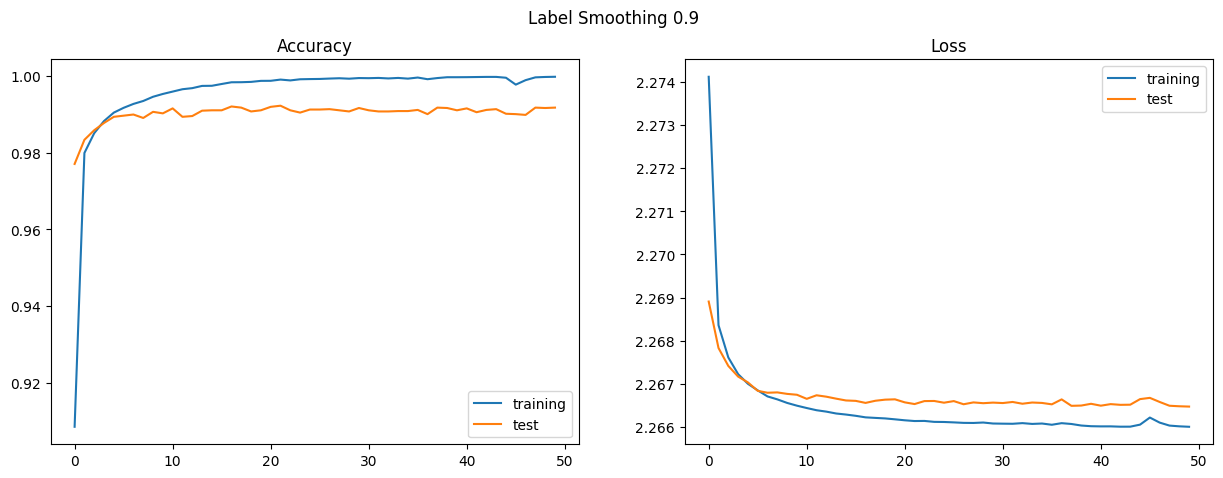

In [7]:
""" 展示训练过程准确率以及损失变化 """
plt.figure(figsize=(15, 5))

idx = [_ for _ in range(EPOCH)]
plt.subplot(1, 2, 1)
plt.plot(idx, train_accs, label='training')
plt.plot(idx, test_accs, label='test')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(idx, train_losses, label='training')
plt.plot(idx, test_losses, label='test')
plt.legend()
plt.title('Loss')

plt.suptitle(f'Label Smoothing {LS_LAMBDA}')
plt.show()

In [8]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'num_epoch': epoch,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
}

result_path = f'./save_model/' + str(EPOCH) + 'epoch'
if not os.path.isdir(result_path):
    os.makedirs(result_path)
torch.save(state, result_path + f'/mnist_lenet5_ls{LS_LAMBDA}.pth')

### 2.2.2 验证Label Smoothing效果

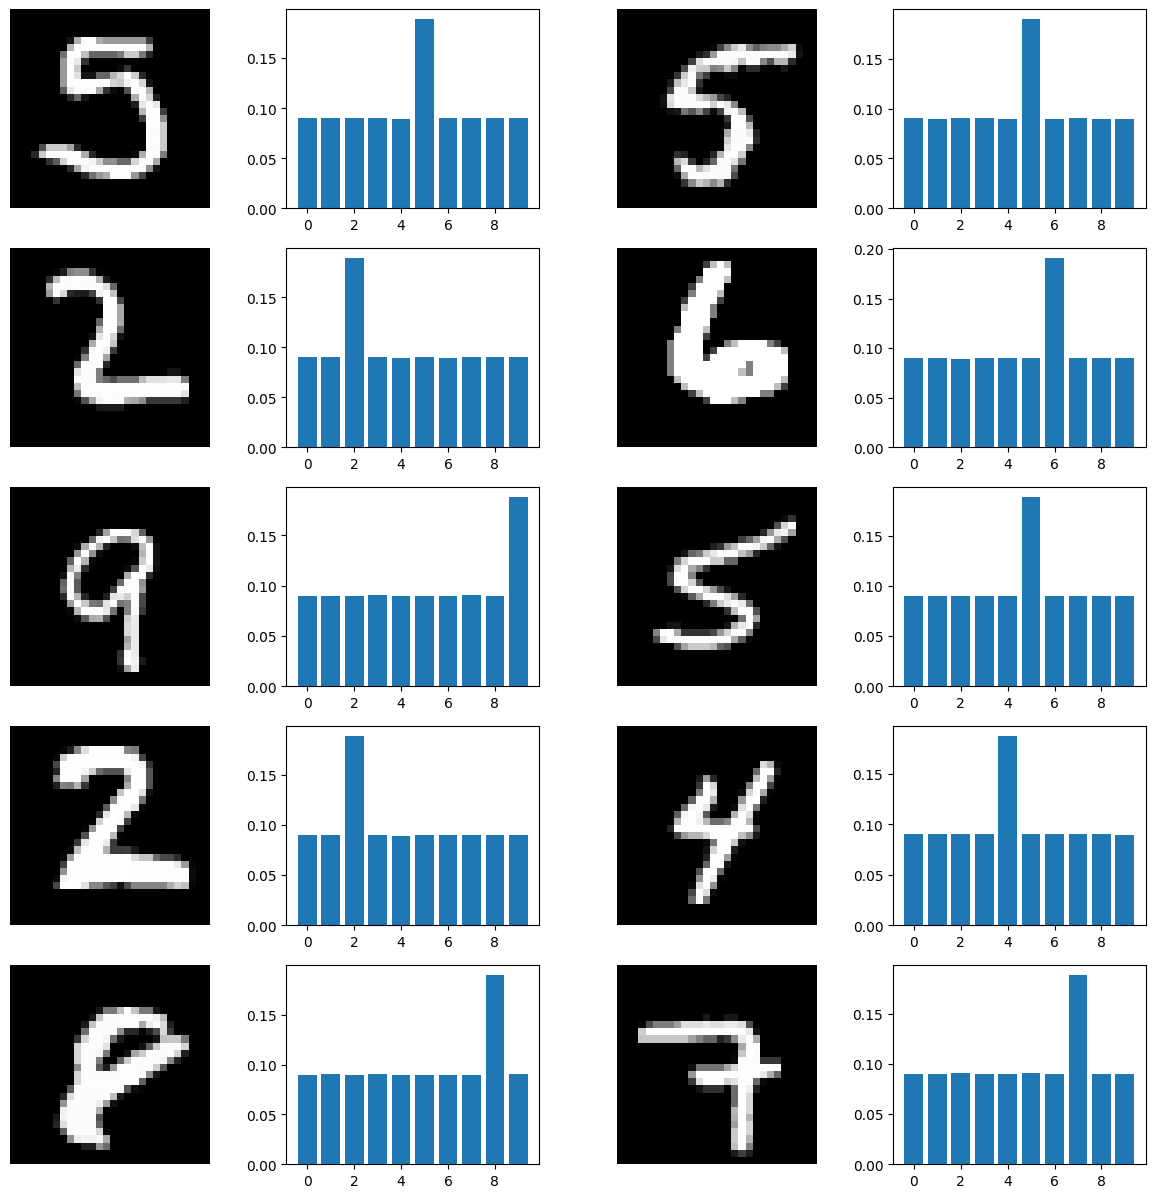

In [9]:
# 加载模型
from models import LeNet5

model_results = torch.load('./save_model/50epoch/mnist_lenet5_ls0.9.pth')  # 加载模型

label_smoothing_net = LeNet5()
label_smoothing_net.load_state_dict(model_results['net'])
label_smoothing_net = label_smoothing_net.to(device)
label_smoothing_net.eval()


# 加载一部分样本
for img, lbl in test_loader:
    # 此处如果test_loader的batch_size小于10会产生下标越界的错误
    img = img[:10].to(device)
    lbl = lbl[:10].to(device)
    break


logits = label_smoothing_net(img)
p = F.softmax(logits, dim=-1)

plt.figure(figsize=(15, 15))
for i in range(10):
    plt.subplot(5, 4, 2 * i + 1)
    plt.imshow(img[i].squeeze(0).cpu(), cmap='gray')
    plt.axis('off')

    plt.subplot(5, 4, 2 * i + 2)
    plt.bar([_ for _ in range(10)], p[i].detach().cpu().numpy())

plt.show()

可以看到，模型输出的概率很好地拟合了Label Smoothing软标签。

### 2.2.3 鲁棒性测试

In [10]:
class LinfPGD(nn.Module):
    def __init__(self,
                 net,
                 eps=8 / 255,
                 step_size=2 / 255,
                 step=10,
                 random_start=True,
                 criterion=F.cross_entropy):
        """
        参数说明：
        net: 待攻击的模型
        eps, step_size, step: 攻击的迭代参数
        random_start: 控制攻击迭代开始前是否添加随机扰动
        criterion: 攻击所使用的损失函数

        LinfPGD类的默认构造参数实现的是10步的Linf PGD攻击，
        但正如在设计之初所提到的那样，LinfPGD类可以同时实现
        FGSM, PGD, CW三种攻击，比如：
         - 设置参数step=1, random_start=False，并使用相同
           的step_size和eps，以实
           现FGSM攻击
         - 设置参数criterion为CW损失，以实现CW攻击
        """
        super(LinfPGD, self).__init__()
        self.net = net
        self.eps = eps
        self.step_size = step_size
        self.step = step
        self.random_start = random_start
        self.criterion = criterion

    def forward(self, inputs):
        x, y = inputs

        up = torch.clamp(x + self.eps, 0., 1.)
        down = torch.clamp(x - self.eps, 0., 1.)

        if self.random_start:
            t = 2 * torch.rand(x.shape).to(x.device).detach() - 1
            x_adv = x + self.eps * t
        else:
            x_adv = x

        x_adv = torch.max(torch.min(x_adv, up), down)
        with torch.enable_grad():
            for _ in range(self.step):
                x_adv = x_adv.requires_grad_()
                logits = self.net(x_adv)
                loss = self.criterion(logits, y)
                grad = torch.autograd.grad(loss, x_adv)[0]
                x_adv = x_adv + self.step_size * torch.sign(grad)
                x_adv = torch.max(torch.min(x_adv, up), down).clone().detach()

        return x_adv

In [11]:
"""
    除了整合攻击算法的实现以外，我们将实现一个用于测试的函数，其目标是能够方便地执行标
准测试、不同攻击的鲁棒性测试，并返回我们想要的结果。
"""
import math


def load_mnist_test(n_examples=None, download=False, root='./data/'):
    """
    我们并非每次都测试整个测试集的样本，本函数用于快速地加载指定个数的MNIST测试集样本

    参数说明：
    n_examples: 加载样本的个数。如果为None或大于总样本数，则加载所有样本；否则将加载
    MNIST测试集中前n_examples个样本与标签
    download: 是否下载数据集
    root: 数据集存放路径
    """
    batch_size = 100
    test_dataset = torchvision.datasets.MNIST(root=root, train=False, download=download, transform=transforms.ToTensor())
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    x_test, y_test = [], []
    for i, (x, y) in enumerate(test_loader):
        x_test.append(x)
        y_test.append(y)
        if n_examples is not None and batch_size * i >= n_examples:
            break
    x_test_tensor = torch.cat(x_test)
    y_test_tensor = torch.cat(y_test)

    if n_examples is not None:
        x_test_tensor = x_test_tensor[:n_examples]
        y_test_tensor = y_test_tensor[:n_examples]

    return x_test_tensor, y_test_tensor


@torch.no_grad()
def test(classifier, samples, labels, bs=100, mode='clean'):
    """
    参数说明：
    classifier: 待测试的分类器
    samples: 待测试的样本
    labels: 样本标签
    bs: 测试时的batch_size
    mode: 测试模型，支持的选项列表：['attack', 'clean']

    对于本函数来说，classifier只要返回的是类似于logits或概率的向量即可，其分类过程并不
    重要。换句话说，它可以是一个简单的cnn，也可以是包含先攻击后分类两个过程以测试鲁棒性。
    很快，我们将看到如何使用此函数快速地执行FGSM, PGD, CW测试。

    返回值说明：
    准确率, 预测列表
    """
    n = samples.shape[0]
    correct = 0
    lens = math.ceil(n / bs)
    count = 0

    preds = []
    for i in range(lens):
        idx_b = i * bs
        idx_e = min((i + 1) * bs, n)
        x = samples[idx_b:idx_e].cuda()
        y = labels[idx_b:idx_e].cuda()

        if mode == 'attack':
            # 包含攻击流程的分类器需要 y（ground truth）来执行攻击
            pred = classifier((x, y)).argmax(-1)
        elif mode == 'clean':
            pred = classifier(x).argmax(-1)
        else:
            raise NotImplementedError
        
        preds.append(pred.cpu())
        correct += pred.eq(y).sum().item()
        count += y.shape[0]

    preds = torch.cat(preds)

    return 100 * correct / n, preds

In [12]:
# 定义CW损失
def CWLoss(logits, targets, kappa=0, targeted=False):
    y_onehot = torch.nn.functional.one_hot(targets, 10).to(torch.float)

    real = torch.sum(y_onehot * logits, dim=1)
    other, _ = torch.max((1 - y_onehot) * logits - y_onehot * 1e4, dim=1)

    # 有些代码中使用relu()代替，效果相同
    if targeted:
        loss = torch.sum(torch.clamp(other - real + kappa, 0))
    # 若想实现非目标攻击，只需传入真实标签，将(other - real)改为(real - other)即可
    else:
        loss = torch.sum(torch.clamp(real - other + kappa, 0))

    return -loss

# 定义攻击参数
LS_FGSM_kwargs = dict(net=label_smoothing_net, eps=0.1, step=1, step_size=0.1, random_start=False)
LS_PGD_kwargs = dict(net=label_smoothing_net, eps=0.1, step=20, step_size=0.025, random_start=True)
LS_CW_kwargs = dict(net=label_smoothing_net, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
LS_FGSM = LinfPGD(**LS_FGSM_kwargs)
LS_PGD = LinfPGD(**LS_PGD_kwargs)
LS_CW = LinfPGD(**LS_CW_kwargs)


# 加载样本
imgs, lbls = load_mnist_test()

In [13]:
# 执行标准测试
cln_acc, cln_pred = test(label_smoothing_net, imgs, lbls, bs=250, mode='clean')
logger.info(f'label smoothing {LS_LAMBDA} Clean Acc: {cln_acc:.2f}')

 31768 20260201 17:38:21 label smoothing 0.9 Clean Acc: 99.18


In [14]:
# 执行FGSM鲁棒性测试
fgsm_adversary = nn.Sequential(LS_FGSM,              # 以(样本, 标签)为输入，输出针对label_smoothing_net的FGSM对抗性样本
                               label_smoothing_net   # 输入样本，输出分类结果
                 )
fgsm_acc, fgsm_pred = test(fgsm_adversary, imgs, lbls, bs=250, mode='attack')

logger.info(f'label smoothing {LS_LAMBDA} FGSM Acc: {fgsm_acc:.2f}')

 31768 20260201 17:38:21 label smoothing 0.9 FGSM Acc: 95.10


` nn.Sequential `用于将不同的nn.Module对象按照指定顺序串联起来，形成一个新的nn.Module对象。我们曾在LeNet5的实现中使用过` nn.Sequential `，用于快速连接卷积层、激活层和池化层。在此处，` nn.Sequential `用于将攻击过程和分类过程连接起来，以快速实现可用于鲁棒性测试的分类过程。

In [15]:
# 执行PGD, CW鲁棒性测试
pgd_acc, pgd_pred = test(nn.Sequential(LS_PGD, label_smoothing_net), imgs, lbls, bs=250, mode='attack')
logger.info(f'label smoothing {LS_LAMBDA} PGD Acc: {pgd_acc:.2f}')

cw_acc, cw_pred = test(nn.Sequential(LS_CW, label_smoothing_net), imgs, lbls, bs=250, mode='attack')
logger.info(f'label smoothing {LS_LAMBDA} CW Acc: {cw_acc:.2f}')


 31768 20260201 17:38:25 label smoothing 0.9 PGD Acc: 83.58
 31768 20260201 17:38:29 label smoothing 0.9 CW Acc: 76.89


In [17]:
"""
    测试不使用Label Smoothing的标准模型的鲁棒性
"""

# 加载模型，模型来自《对抗性攻击》课程第5节
std_model_results = torch.load('./save_model/50epoch/mnist_lenet5_ls0.1.pth')

std_net = LeNet5()
std_net.load_state_dict(std_model_results['net'])
std_net = std_net.to(device)
std_net.eval()

# 创建攻击
STD_FGSM_kwargs = dict(net=std_net, eps=0.1, step=1, step_size=0.1, random_start=False)
STD_PGD_kwargs = dict(net=std_net, eps=0.1, step=20, step_size=0.025, random_start=True)
STD_CW_kwargs = dict(net=std_net, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

STD_FGSM = LinfPGD(**STD_FGSM_kwargs)
STD_PGD = LinfPGD(**STD_PGD_kwargs)
STD_CW = LinfPGD(**STD_CW_kwargs)

# 分别执行Clean, FGSM, PGD, CW测试
std_cln_acc, std_cln_pred = test(std_net, imgs, lbls, bs=250, mode='clean')
logger.info(f'Standard Clean Acc: {std_cln_acc:.2f}')

std_fgsm_acc, std_fgsm_pred = test(nn.Sequential(STD_FGSM, std_net), imgs, lbls, bs=250, mode='attack')
logger.info(f'Standard FGSM Acc: {std_fgsm_acc:.2f}')

std_pgd_acc, std_pgd_pred = test(nn.Sequential(STD_PGD, std_net), imgs, lbls, bs=250, mode='attack')
logger.info(f'Standard PGD Acc: {std_pgd_acc:.2f}')

std_cw_acc, std_cw_pred = test(nn.Sequential(STD_CW, std_net), imgs, lbls, bs=250, mode='attack')
logger.info(f'Standard CW Acc: {std_cw_acc:.2f}')

 31768 20260201 17:42:00 Standard Clean Acc: 99.14
 31768 20260201 17:42:00 Standard FGSM Acc: 92.17
 31768 20260201 17:42:09 Standard PGD Acc: 74.00
 31768 20260201 17:42:34 Standard CW Acc: 57.52


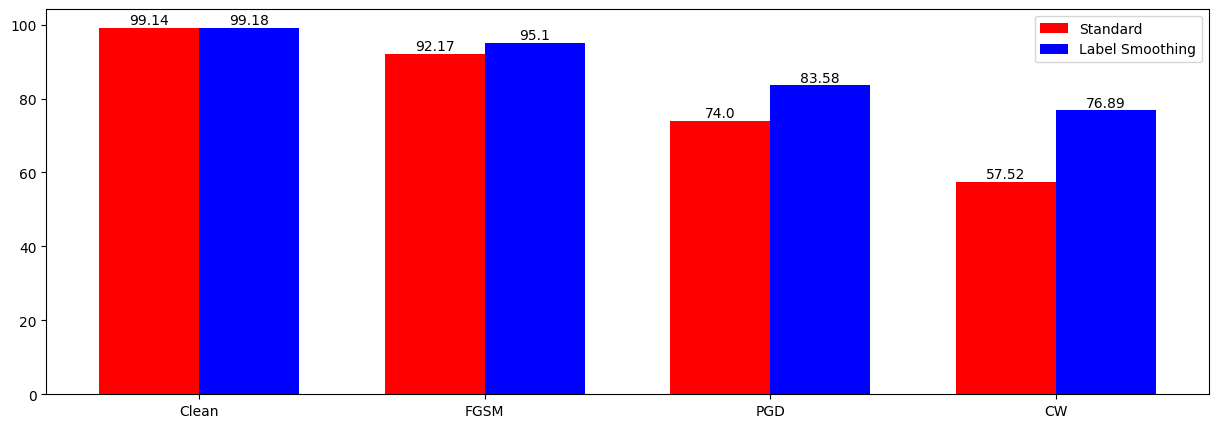

In [18]:
"""
    对比标准模型与Label Smoothing模型的性能
"""
import numpy as np

test_item_list = ['Clean', 'FGSM', 'PGD', 'CW']

std_acc_list = [std_cln_acc, std_fgsm_acc, std_pgd_acc, std_cw_acc]
ls_acc_list = [cln_acc, fgsm_acc, pgd_acc, cw_acc]

index = np.arange(len(test_item_list))

# 设置柱形图宽度
bar_width = 0.35

# 绘图
plt.figure(figsize=(15, 5))

# 绘制条形图
std_bar = plt.bar(index, std_acc_list, bar_width, color='r', label='Standard')
ls_bar = plt.bar(index + bar_width, ls_acc_list, bar_width, color='b', label='Label Smoothing')

# 在条形图上标记数据
for idx, std_acc, ls_acc in zip(index, std_acc_list, ls_acc_list):
    plt.text(idx, std_acc, std_acc, ha='center', va='bottom')
    plt.text(idx + bar_width, ls_acc, ls_acc, ha='center', va='bottom')

# 设置坐标轴和图例
plt.xticks(index + bar_width * 0.5, test_item_list)
plt.legend()

plt.show()

可以明显地看出，使用Label Smoothing能够显著地提升模型的鲁棒性能。

## 2.3 补充

关于` with torch.enable_grad():`, ` with torch.no_grad(): `和` @torch.no_grad() `的说明：

我们在训练时，会显式地使用` loss.backward() `来进行梯度的反向传播，
实际上，在我们调用 ` loss.backward() ` 之前，PyTorch已经为梯度计算做了诸多准备，比如计算图的建立，梯度空间的预留。
然而，我们在测试时并不需要这些工作，因此，PyTorch提供了`torch.no_grad`来禁用梯度的计算，通过使用`with`关键字和函数装饰器可以分别实现`with`作用域内和函数内的梯度禁用。

那么如何在` torch.no_grad `的作用域内的一个更小的作用域进行梯度计算呢？比如，我们在鲁棒性测试中，攻击的执行需要开启梯度计算，而针对对抗性样本的分类则无须梯度计算。在这种情况下，我们首先使用` torch.no_grad `禁用整个测试流程的梯度计算，然后使用` torch.enable_grad `开启攻击流程中的梯度计算。

参考：[PyTorch torch.no_grad](https://pytorch.org/docs/stable/generated/torch.no_grad.html?highlight=no_grad#torch.no_grad)、[PyTorch torch.enable_grad](https://pytorch.org/docs/stable/generated/torch.enable_grad.html?highlight=enable_grad#torch.enable_grad)、[Python with关键字](https://www.runoob.com/python3/python-with.html)、[Python函数装饰器](https://www.runoob.com/w3cnote/python-func-decorators.html)